In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import scanpy as sc

sns.set_theme(style='white')
       # scalpels

pd.set_option('display.max_rows', 100)
plt.rcParams['svg.fonttype'] = 'none'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load PSI rankings and define quartiles ---
new_metrics = pd.read_parquet("new_metrics_large_all.parquet")
PSI_rankings = pd.read_parquet("PSI_rankings_large.parquet")
PSI_rankings = PSI_rankings[PSI_rankings.perturbation.isin(new_metrics.perturb.unique())]
sorted_psi = PSI_rankings.sort_values('global_PSI')

n = len(sorted_psi)
q25, q50, q75 = n // 4, n // 2, 3 * n // 4
quartile_map = {}
for p in sorted_psi.iloc[:q25]['perturbation']:
    quartile_map[p] = 'Q1 (Sledgehammers)'
for p in sorted_psi.iloc[q25:q50]['perturbation']:
    quartile_map[p] = 'Q2'
for p in sorted_psi.iloc[q50:q75]['perturbation']:
    quartile_map[p] = 'Q3'
for p in sorted_psi.iloc[q75:]['perturbation']:
    quartile_map[p] = 'Q4 (Scalpels)'





In [5]:
datasets = {
    'K562_large': '/cwork/hl489/Pertb_benchmark/DataSet2/K562_large/hvg5000/filter_hvg5000_logNor.h5ad',
    'hepg2_large': '/cwork/hl489/Pertb_benchmark/DataSet2/hepg2_large/hvg5000/filter_hvg5000_logNor.h5ad',
    'rpe1_large': '/cwork/hl489/Pertb_benchmark/DataSet2/rpe1_large/hvg5000/filter_hvg5000_logNor.h5ad',
    'jurkat_large': '/cwork/hl489/Pertb_benchmark/DataSet2/jurkat_large/hvg5000/filter_hvg5000_logNor.h5ad',
    'HEK_large': '/cwork/hl489/Pertb_benchmark/DataSet2/HEK_large/hvg5000/filter_hvg5000_logNor.h5ad',
    'HCT_large': '/cwork/hl489/Pertb_benchmark/DataSet2/HCT_large/hvg5000/filter_hvg5000_logNor.h5ad'
}

de_files = {
    'K562': 'de_results/K562_large_de_ttest.parquet',
    'HepG2': 'de_results/hepg2_large_de_ttest.parquet',
    'RPE1': 'de_results/rpe1_large_de_ttest.parquet',
    'Jurkat': 'de_results/jurkat_large_de_ttest.parquet',
    'HEK293T': 'de_results/HEK_large_de_ttest.parquet',
    'HCT116': 'de_results/HCT_large_de_ttest.parquet',
}


# ensg_to_gene = {}
# for name, path in datasets.items():
#     ad = sc.read_h5ad(path, backed='r')
#     ensg_to_gene.update(dict(zip(ad.var.index, ad.var['gene_name'])))
#     del ad


KeyboardInterrupt: 

In [7]:
results = {}
for name, path in datasets.items():
    adata = sc.read_h5ad(path, backed='r')
    print(name)
    results[name] = adata


K562_large
hepg2_large
rpe1_large
jurkat_large
HEK_large
HCT_large


In [19]:
for k, v in results.items():
    
    if k in ['HEK_large', 'HCT_large']:
    
        print(k, v.obs[v.obs.gene_target != "Non-Targeting"].shape)
    
    else:
        print(k, v.obs[v.obs.gene != "non-targeting"].shape)

K562_large (465400, 17)
hepg2_large (133593, 15)
rpe1_large (224640, 17)
jurkat_large (239186, 15)
HEK_large (416972, 11)
HCT_large (314708, 11)


In [16]:
results['HCT_large'].obs

,sample,num_features,guide_target,gene_target,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,pass_guide_filter,perturbation,n_genes
ACTGCAATCGCGAAAG-HCT116_Batch73,HCT116_Batch73,2,AAAS_P1P2-1|AAAS_P1P2-2,AAAS,3873,10049.0,166.0,1.651906,True,AAAS,3873
AGTGTCGGTCTATGGG-HCT116_Batch88,HCT116_Batch88,2,AAAS_P1P2-1|AAAS_P1P2-2,AAAS,5840,32683.0,202.0,0.618058,True,AAAS,5840
CACTTAGAGCAAGGCA-HCT116_Batch62,HCT116_Batch62,2,AAAS_P1P2-1|AAAS_P1P2-2,AAAS,7516,32083.0,1979.0,6.168376,True,AAAS,7516
AGCGGTAAGCTATCGA-HCT116_Batch7,HCT116_Batch7,2,AAAS_P1P2-1|AAAS_P1P2-2,AAAS,5117,15759.0,737.0,4.676692,True,AAAS,5117
CTCTCGGGTGTCGATG-HCT116_Batch53,HCT116_Batch53,2,AAAS_P1P2-1|AAAS_P1P2-2,AAAS,3325,8856.0,219.0,2.472900,True,AAAS,3325
...,...,...,...,...,...,...,...,...,...,...,...
GTAGATTTCAACCATG-HCT116_Batch15,HCT116_Batch15,2,non-targeting_01721|non-targeting_01433,Non-Targeting,4756,16056.0,407.0,2.534878,True,control,4756
GTTGTGGGTATCCTAT-HCT116_Batch2,HCT116_Batch2,2,non-targeting_00284|non-targeting_01289,Non-Targeting,6031,27922.0,810.0,2.900938,True,control,6031
ACGCATGGTGTGTCAG-HCT116_Batch71,HCT116_Batch71,2,non-targeting_01355|non-targeting_01062,Non-Targeting,4708,15440.0,623.0,4.034974,True,control,4708
ATAAGTCTCACACGGT-HCT116_Batch97,HCT116_Batch97,2,non-targeting_00351|non-targeting_02158,Non-Targeting,6727,30169.0,1058.0,3.506911,True,control,6727


In [ ]:
from scipy.stats import mannwhitneyu

sns.set_theme(style="white")
for ct, path in de_files.items():
    de = pd.read_parquet(path)
    de['quartile'] = de['perturbation'].map(quartile_map)
    de = de.dropna(subset=['quartile'])
    de['neg_log10_padj'] = -np.log10(de['pvals_adj'].clip(lower=1e-300))
    summary = de.groupby(['perturbation', 'quartile'])['neg_log10_padj'].median().reset_index()
    plot_data = summary[summary['quartile'].isin(order)]
    
    # Mann-Whitney U test
    sledge = plot_data[plot_data['quartile'] == 'Q1 (Sledgehammers)']['neg_log10_padj'].dropna()
    scalpel = plot_data[plot_data['quartile'] == 'Q4 (Scalpels)']['neg_log10_padj'].dropna()
    print(f"Sledge - NaN: {sledge.isna().sum()}, Inf: {np.isinf(sledge).sum()}, len: {len(sledge)}")
    print(f"Scalpel - NaN: {scalpel.isna().sum()}, Inf: {np.isinf(scalpel).sum()}, len: {len(scalpel)}")


    # Also check for inf
    sledge = sledge[np.isfinite(sledge)]
    scalpel = scalpel[np.isfinite(scalpel)]

    if len(sledge) > 0 and len(scalpel) > 0:
        stat, pval = mannwhitneyu(sledge, scalpel, alternative='two-sided')
    else:
        pval = np.nan

    
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.violinplot(data=plot_data, y='quartile', x='neg_log10_padj', order=order, palette=palette, 
                   ax=ax, linewidth=0.5, orient='h', cut=0, inner='box', width=0.5)
    ax.set_yticklabels(['Sledgehammers', 'Scalpels'], fontsize=5)
    ax.set_xlabel('Median $-\\log_{10}$(adj. p-value)', fontsize=5)
    ax.set_ylabel('')
    
    # Format p-value
    if pval < 1e-10:
        pval_str = f'p = {pval:.1e}'
    elif pval < 0.001:
        pval_str = f'p = {pval:.1e}'
    else:
        pval_str = f'p = {pval:.3f}'
    ax.set_title(f'{ct} (Mann-Whitney {pval_str})', fontsize=5)
    
    ax.tick_params(axis='x', labelsize=5, direction='out', length=4, width=0.8)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    # plt.savefig(f'FigSupp/FigSupp_DE_effect_{ct}.png', bbox_inches='tight', dpi=300)
    # plt.savefig(f'FigSupp/FigSupp_DE_effect_{ct}.svg', bbox_inches='tight', dpi=300)
    plt.show()




NameError: name 'de_files' is not defined

In [4]:
# import scanpy as sc
# import pandas as pd
# import os


# datasets = {
    
#     'HEK_large': '/cwork/hl489/Pertb_benchmark/DataSet2/HEK_large/hvg5000/filter_hvg5000_logNor.h5ad',
#     'HCT_large': '/cwork/hl489/Pertb_benchmark/DataSet2/HCT_large/hvg5000/filter_hvg5000_logNor.h5ad',
# }


# out_dir = '/cwork/hl489/perturbBench/plotting_hammers/de_results'
# os.makedirs(out_dir, exist_ok=True)

# for name, path in datasets.items():
#     print(f"Processing {name}...")
#     ad = sc.read_h5ad(path)
#     sc.pp.highly_variable_genes(ad, n_top_genes=2000)
#     ad = ad[:, ad.var['highly_variable']].copy()
    
#     sc.tl.rank_genes_groups(ad, groupby='gene_target', reference='Non-Targeting', method='t-test')
    
#     de_results = (
#         sc.get.rank_genes_groups_df(ad, group=None)
#           .query("group != 'Non-Targeting'")
#           .rename(columns={'group': 'perturbation'})
#     )
    
#     de_results.to_parquet(f'{out_dir}/{name}_de_ttest.parquet', index=False)
#     print(f"  Saved {name}: {de_results.shape}")
#     del ad


In [6]:
# ensg_to_gene

In [15]:
from itertools import combinations
from scipy.stats import mannwhitneyu

# 1. For each perturbation × cell type, get significant genes
sig_genes = {}  # (perturbation, cell_type) -> set of gene names
padj_thresh = 0.05

for ct, path in de_files.items():
    de = pd.read_parquet(path)
    de['names'] = de['names'].map(lambda x: ensg_to_gene.get(x, x))
    de['quartile'] = de['perturbation'].map(quartile_map)
    de = de.dropna(subset=['quartile'])
    for pert in de['perturbation'].unique():
        sig = de[(de['perturbation'] == pert) & (de['pvals_adj'] < padj_thresh)]['names']
        sig_genes[(pert, ct)] = set(sig)


# 2. For each perturbation, compute mean pairwise Jaccard across cell types
cell_types = list(de_files.keys())
records = []

for pert in quartile_map:
    sets = {ct: sig_genes.get((pert, ct), set()) for ct in cell_types}
    jaccards = []
    for ct1, ct2 in combinations(cell_types, 2):
        s1, s2 = sets[ct1], sets[ct2]
        if len(s1 | s2) > 0:
            jaccards.append(len(s1 & s2) / len(s1 | s2))
        else:
            jaccards.append(0)
    records.append({
        'perturbation': pert,
        'quartile': quartile_map[pert],
        'mean_jaccard': np.mean(jaccards),
        'n_sig_median': np.median([len(sets[ct]) for ct in cell_types]),
    })

overlap_df = pd.DataFrame(records)




In [25]:
overlap_df.mean_jaccard.describe()

count    2269.000000
mean        0.025669
std         0.019617
min         0.000000
25%         0.010308
50%         0.020845
75%         0.036419
max         0.120475
Name: mean_jaccard, dtype: float64

Mann-Whitney U (hammers > scalpels): U=295303, p=6.31e-131
Median Jaccard — Sledgehammers: 0.043, Scalpels: 0.008


/hpc/home/hl489/tmp/ipykernel_3438522/3062904450.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, y='quartile', x='mean_jaccard', order=order, palette=palette,
/hpc/home/hl489/tmp/ipykernel_3438522/3062904450.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Sledgehammers', 'Scalpels'], fontsize=5)


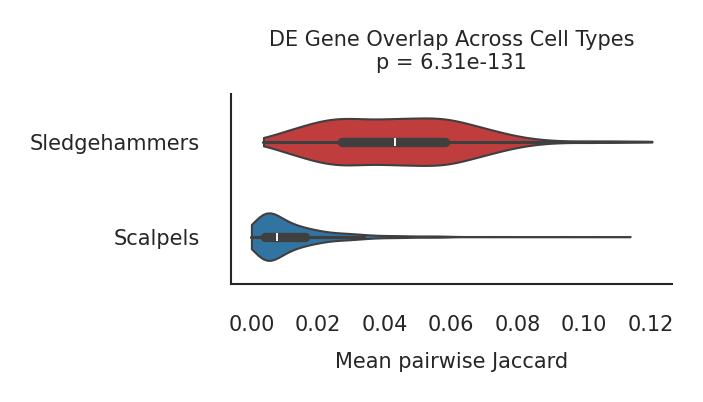

In [19]:
# 3. Statistical test: sledgehammers vs scalpels
hammers = overlap_df[overlap_df['quartile'] == 'Q1 (Sledgehammers)']['mean_jaccard']
scalpels = overlap_df[overlap_df['quartile'] == 'Q4 (Scalpels)']['mean_jaccard']
stat, pval = mannwhitneyu(hammers, scalpels, alternative='greater')
print(f"Mann-Whitney U (hammers > scalpels): U={stat:.0f}, p={pval:.2e}")
print(f"Median Jaccard — Sledgehammers: {hammers.median():.3f}, Scalpels: {scalpels.median():.3f}")

# 4. Plot
plot_data = overlap_df[overlap_df['quartile'].isin(['Q1 (Sledgehammers)', 'Q4 (Scalpels)'])]

fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
sns.violinplot(data=plot_data, y='quartile', x='mean_jaccard', order=order, palette=palette, 
               ax=ax, linewidth=0.5, orient='h', cut=0, inner='box', width=0.5)
ax.set_yticklabels(['Sledgehammers', 'Scalpels'], fontsize=5)
ax.set_xlabel('Mean pairwise Jaccard', fontsize=5)
ax.set_ylabel('')
ax.set_title(f'DE Gene Overlap Across Cell Types\np = {pval:.2e}', fontsize=5)
ax.tick_params(axis='x', labelsize=5, direction='out', length=4, width=0.8)
ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
plt.tight_layout()
plt.savefig('FigSupp/FigSupp_DE_jaccard_overlap.png', bbox_inches='tight', dpi=300)
plt.savefig('FigSupp/FigSupp_DE_jaccard_overlap.svg', bbox_inches='tight', dpi=300)
plt.show()

In [30]:
overlap_df.quartile.unique()

array(['Q1 (Sledgehammers)', 'Q2', 'Q3', 'Q4 (Scalpels)'], dtype=object)

Observed sledgehammer median Jaccard: 0.0431
Null median (mean ± std): 0.0209 ± 0.0008
Permutation p-value: 0.0000e+00


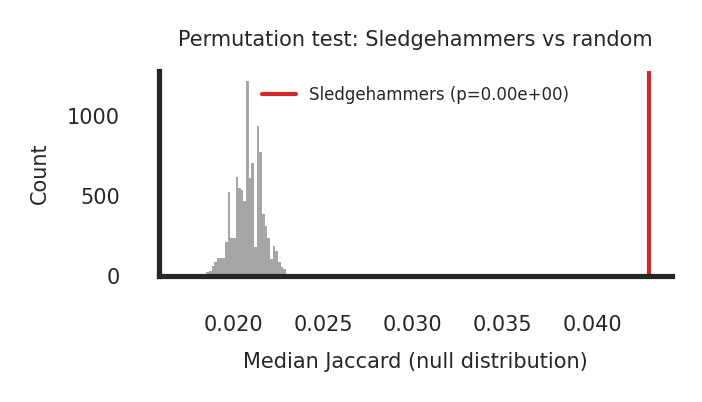

In [26]:
from numpy.random import default_rng

rng = default_rng(42)
n_hammers = len(hammers)
all_jaccards = overlap_df['mean_jaccard'].values
observed_median = hammers.median()

n_perms = 10000
null_medians = []
for _ in range(n_perms):
    sample = rng.choice(all_jaccards, size=n_hammers, replace=False)
    null_medians.append(np.median(sample))

null_medians = np.array(null_medians)
perm_pval = (null_medians >= observed_median).sum() / n_perms

print(f"Observed sledgehammer median Jaccard: {observed_median:.4f}")
print(f"Null median (mean ± std): {null_medians.mean():.4f} ± {null_medians.std():.4f}")
print(f"Permutation p-value: {perm_pval:.4e}")

fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
ax.hist(null_medians, bins=50, color='grey', alpha=0.7, edgecolor='none')
ax.axvline(observed_median, color='#d62728', linewidth=1, label=f'Sledgehammers (p={perm_pval:.2e})')
ax.set_xlabel('Median Jaccard (null distribution)', fontsize=5)
ax.set_ylabel('Count', fontsize=5)
ax.set_title('Permutation test: Sledgehammers vs random', fontsize=5)
ax.legend(fontsize=4, frameon=False)
ax.tick_params(labelsize=5)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [27]:
observed_scalpel = scalpels.median()
perm_pval_scalpel = (null_medians <= observed_scalpel).sum() / n_perms
print(f"Scalpel median: {observed_scalpel:.4f}, p={perm_pval_scalpel:.4e}")


Scalpel median: 0.0078, p=0.0000e+00
